# Ethereum Storage Slot & Account Sharing Analyzer

For each block, counts SLOAD/SSTORE operations on each `(contract, slot)` pair and CALL-family invocations on each contract. Reports four distributions:

| Metric | Key | Counts | Question |
|---|---|---|---|
| **N(s,B)** | `(block, contract, slot)` | SLOAD+SSTORE ops | How many ops hit the same slot in a block? |
| **N(c,B)** | `(block, contract)` | entry + CALL-family | How many calls hit the same account in a block? |
| **N(s,T)** | `(tx, contract, slot)` | SLOAD+SSTORE ops | How many ops does a tx do on the same slot? |
| **N(c,T)** | `(tx, contract)` | entry + CALL-family | How many times does a tx call the same account? |

Contract attribution follows EVM storage semantics:
- **CALL / STATICCALL**: new frame's storage is the callee
- **DELEGATECALL / CALLCODE**: storage inherits from the caller
- Precompile addresses (`0x01..0x0a`) are excluded from account distributions

**Requirements:** `pip install requests tqdm matplotlib`

In [1]:
import json
import sys
from collections import defaultdict

import matplotlib.pyplot as plt
import requests
from tqdm import tqdm

%matplotlib inline

## Configuration

In [ ]:
RPC_URL = "https://YOUR_RPC_URL_HERE"  # must support debug_traceBlockByNumber
# Pick ONE of these modes:
SINGLE_BLOCK = None           # e.g. 22000000
START_BLOCK  = None           # e.g. 22000000 (uses COUNT blocks from here)
COUNT        = 10             # number of blocks when using START_BLOCK
RECENT       = 5              # number of recent blocks (used if SINGLE_BLOCK and START_BLOCK are None)

## Core functions

In [4]:
CALL_OPS_OWN_STORAGE = {"CALL", "STATICCALL"}
CALL_OPS_INHERIT_STORAGE = {"DELEGATECALL", "CALLCODE"}
CREATE_OPS = {"CREATE", "CREATE2"}
PRECOMPILES = {"0x" + f"{i:040x}" for i in range(1, 0x0b)}


def rpc(url, method, params, timeout=300):
    resp = requests.post(
        url,
        json={"jsonrpc": "2.0", "id": 1, "method": method, "params": params},
        headers={"Content-Type": "application/json"},
        timeout=timeout,
    )
    resp.raise_for_status()
    body = resp.json()
    if "error" in body:
        raise RuntimeError(f"RPC error {body['error']['code']}: {body['error']['message']}")
    return body["result"]


def latest_block(url):
    return int(rpc(url, "eth_blockNumber", []), 16)


def normalize_addr(raw):
    h = raw.lower()
    if h.startswith("0x"):
        h = h[2:]
    h = h.zfill(40) if len(h) < 40 else h[-40:]
    return "0x" + h


def analyze_block(url, block_num):
    block_data = rpc(url, "eth_getBlockByNumber", [hex(block_num), True])
    tx_entry_addrs = []
    for i, tx in enumerate(block_data.get("transactions", [])):
        to = tx.get("to")
        tx_entry_addrs.append(to.lower() if to else f"0xcreate_tx{i}")

    traces = rpc(url, "debug_traceBlockByNumber", [
        hex(block_num),
        {"disableMemory": True, "disableReturnData": True, "disableStack": False},
    ], timeout=600)

    slot_ops = defaultdict(int)
    account_calls = defaultdict(int)
    tx_slot_access = defaultdict(int)
    tx_account_call = defaultdict(int)

    for tx_idx, tx_trace in enumerate(traces):
        result = tx_trace.get("result", tx_trace)
        struct_logs = result.get("structLogs", [])

        entry = tx_entry_addrs[tx_idx] if tx_idx < len(tx_entry_addrs) else "unknown"
        storage_stack = [entry]
        if entry not in PRECOMPILES:
            account_calls[entry] += 1
            tx_account_call[(tx_idx, entry)] += 1

        prev_op = prev_stack = None
        prev_depth = 1
        create_counter = 0

        for step in struct_logs:
            op = step.get("op", "")
            depth = step.get("depth", 1)
            stack = step.get("stack", [])

            if op in CALL_OPS_OWN_STORAGE or op in CALL_OPS_INHERIT_STORAGE:
                if len(stack) >= 2:
                    target = normalize_addr(stack[-2])
                    if target not in PRECOMPILES:
                        account_calls[target] += 1
                        tx_account_call[(tx_idx, target)] += 1

            if depth > prev_depth:
                if prev_op in CALL_OPS_OWN_STORAGE and prev_stack and len(prev_stack) >= 2:
                    storage_stack.append(normalize_addr(prev_stack[-2]))
                elif prev_op in CALL_OPS_INHERIT_STORAGE:
                    storage_stack.append(storage_stack[-1])
                elif prev_op in CREATE_OPS:
                    create_counter += 1
                    storage_stack.append(f"0xcreate_tx{tx_idx}_{create_counter}")
                else:
                    storage_stack.append(storage_stack[-1])
            elif depth < prev_depth:
                while len(storage_stack) > depth:
                    storage_stack.pop()

            if op in ("SLOAD", "SSTORE") and stack:
                raw_slot = stack[-1]
                slot_hex = raw_slot.lstrip("0x").zfill(64).lower()
                contract = storage_stack[-1] if storage_stack else "unknown"
                slot_ops[(contract, slot_hex)] += 1
                tx_slot_access[(tx_idx, contract, slot_hex)] += 1

            prev_op = op
            prev_stack = stack
            prev_depth = depth

    # Statistics
    n_txs = len(traces)
    total_unique_slots = len(slot_ops)
    n_distribution = defaultdict(int)
    for cnt in slot_ops.values():
        n_distribution[cnt] += 1
    multi_access_slots = sum(1 for cnt in slot_ops.values() if cnt > 1)

    top_shared = sorted(
        [(k, c) for k, c in slot_ops.items() if c > 1], key=lambda x: x[1], reverse=True
    )[:15]

    total_unique_accounts = len(account_calls)
    account_n_distribution = defaultdict(int)
    for cnt in account_calls.values():
        account_n_distribution[cnt] += 1
    multi_call_accounts = sum(1 for cnt in account_calls.values() if cnt > 1)

    top_shared_accounts = sorted(
        [(a, c) for a, c in account_calls.items() if c > 1], key=lambda x: x[1], reverse=True
    )[:15]

    tx_slot_distribution = defaultdict(int)
    for cnt in tx_slot_access.values():
        tx_slot_distribution[cnt] += 1

    tx_account_distribution = defaultdict(int)
    for cnt in tx_account_call.values():
        tx_account_distribution[cnt] += 1

    return {
        "block": block_num,
        "total_txs": n_txs,
        "total_unique_slots": total_unique_slots,
        "multi_access_slots": multi_access_slots,
        "multi_access_rate": multi_access_slots / total_unique_slots if total_unique_slots else 0,
        "n_distribution": dict(sorted(n_distribution.items())),
        "top_shared_slots": [
            {"contract": k[0], "slot": k[1], "n_ops": n} for k, n in top_shared
        ],
        "total_unique_accounts": total_unique_accounts,
        "multi_call_accounts": multi_call_accounts,
        "multi_call_rate": multi_call_accounts / total_unique_accounts if total_unique_accounts else 0,
        "account_n_distribution": dict(sorted(account_n_distribution.items())),
        "top_shared_accounts": [
            {"account": a, "n_calls": n} for a, n in top_shared_accounts
        ],
        "tx_slot_distribution": dict(sorted(tx_slot_distribution.items())),
        "tx_account_distribution": dict(sorted(tx_account_distribution.items())),
        "total_tx_slot_entries": sum(tx_slot_distribution.values()),
        "total_tx_account_entries": sum(tx_account_distribution.values()),
    }

## Run analysis

In [5]:
# Determine block list
if SINGLE_BLOCK:
    blocks = [SINGLE_BLOCK]
elif START_BLOCK:
    blocks = list(range(START_BLOCK, START_BLOCK + COUNT))
else:
    tip = latest_block(RPC_URL)
    blocks = list(range(tip - RECENT - 2, tip - 2))

print(f"Analyzing blocks {blocks[0]} -> {blocks[-1]}  ({len(blocks)} total)")
print("Tracer: structLogger  |  ops: SLOAD + SSTORE")
print("Note: large blocks can produce 50-200 MB responses.\n")

results = []
for bn in tqdm(blocks, desc="blocks"):
    try:
        r = analyze_block(RPC_URL, bn)
        results.append(r)
        print(f"  Block {bn}: {r['total_txs']} txs, "
              f"{r['total_unique_slots']} slots, "
              f"{r['total_unique_accounts']} accounts")
    except Exception as e:
        print(f"  Block {bn}: FAILED - {e}", file=sys.stderr)

print(f"\n{len(results)}/{len(blocks)} blocks succeeded")

Analyzing blocks 24891458 -> 24891462  (5 total)
Tracer: structLogger  |  ops: SLOAD + SSTORE
Note: large blocks can produce 50-200 MB responses.



blocks:  20%|██        | 1/5 [00:10<00:42, 10.72s/it]

  Block 24891458: 203 txs, 1553 slots, 425 accounts


blocks:  40%|████      | 2/5 [00:23<00:36, 12.04s/it]

  Block 24891459: 229 txs, 1553 slots, 402 accounts


...

  Block 24891460: 217 txs, 2562 slots, 531 accounts


blocks:  80%|████████  | 4/5 [01:07<00:17, 17.19s/it]

  Block 24891461: 173 txs, 1619 slots, 367 accounts


blocks: 100%|██████████| 5/5 [01:28<00:00, 17.73s/it]

  Block 24891462: 217 txs, 2687 slots, 582 accounts

5/5 blocks succeeded


## Charting helpers

In [6]:
def agg_distribution(results, key):
    agg = defaultdict(int)
    for r in results:
        for n_val, count in r[key].items():
            agg[int(n_val)] += count
    return dict(sorted(agg.items()))


def distribution_stats(d):
    if not d:
        return {}
    total = sum(d.values())
    weighted = sum(int(n) * c for n, c in d.items())
    mean = weighted / total
    cum = 0
    p = {0.50: None, 0.95: None, 0.99: None}
    for k in sorted(d.keys()):
        cum += d[k]
        for pct in p:
            if p[pct] is None and cum / total >= pct:
                p[pct] = k
    n1 = d.get(1, 0)
    shared = sum(c for n, c in d.items() if int(n) >= 2)
    return {
        "total": total, "mean": mean,
        "p50": p[0.50], "p95": p[0.95], "p99": p[0.99],
        "max": max(int(k) for k in d.keys()),
        "n1_pct": n1 / total, "shared_pct": shared / total,
    }


def plot_distribution(d, title, xlabel, ylabel, max_bins=60):
    fig, ax = plt.subplots(figsize=(12, 4.5))
    if not d:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        plt.show()
        return

    items = sorted(d.items(), key=lambda x: int(x[0]))
    if len(items) > max_bins:
        head = items[:max_bins - 1]
        tail_sum = sum(c for _, c in items[max_bins - 1:])
        cap = int(items[max_bins - 1][0])
        xs = [str(int(n)) for n, _ in head] + [f"≥{cap}"]
        ys = [c for _, c in head] + [tail_sum]
    else:
        xs = [str(int(n)) for n, _ in items]
        ys = [c for _, c in items]

    ax.bar(xs, ys, color="#4a7cbf", edgecolor="#1a3a5a", linewidth=0.5)
    if max(ys) / max(1, min(y for y in ys if y > 0)) > 20:
        ax.set_yscale("log")
    if len(xs) > 25:
        ax.tick_params(axis="x", rotation=60, labelsize=8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)

    stats = distribution_stats(d)
    stat_text = (f"total={stats['total']:,}  mean={stats['mean']:.2f}  "
                 f"p50={stats['p50']}  p95={stats['p95']}  p99={stats['p99']}  "
                 f"max={stats['max']}  N=1: {stats['n1_pct']:.1%}  N≥2: {stats['shared_pct']:.1%}")
    ax.text(0.5, -0.18, stat_text, ha="center", va="top", transform=ax.transAxes,
            fontsize=9, color="#555", family="monospace")

    plt.tight_layout()
    plt.show()

## Summary

In [7]:
n = len(results)
if n == 0:
    print("No results to summarize.")
else:
    def avg(key):
        return sum(r[key] for r in results) / n

    block_min = min(r["block"] for r in results)
    block_max = max(r["block"] for r in results)
    total_txs = sum(r["total_txs"] for r in results)

    print(f"Blocks {block_min} - {block_max}  ({n} blocks, {total_txs:,} total txs)\n")
    print(f"  Avg txs/block           : {avg('total_txs'):>8.1f}")
    print(f"  Avg unique slots/block  : {avg('total_unique_slots'):>8.1f}")
    print(f"  Avg multi-access slots  : {avg('multi_access_slots'):>8.1f}")
    print(f"  Avg multi-access rate   : {avg('multi_access_rate'):>8.1%}")
    print(f"  Avg unique accounts     : {avg('total_unique_accounts'):>8.1f}")
    print(f"  Avg multi-call accounts : {avg('multi_call_accounts'):>8.1f}")
    print(f"  Avg multi-call rate     : {avg('multi_call_rate'):>8.1%}")

Blocks 24891458 - 24891462  (5 blocks, 1,039 total txs)

  Avg txs/block           :    207.8
  Avg unique slots/block  :   1994.8
  Avg multi-access slots  :   1387.8
  Avg multi-access rate   :    70.3%
  Avg unique accounts     :    461.4
  Avg multi-call accounts :    172.6
  Avg multi-call rate     :    37.9%


## N(s,B) — Per-block slot accesses

Total SLOAD/SSTORE ops on each `(contract, slot)` within a block, summed across all transactions.

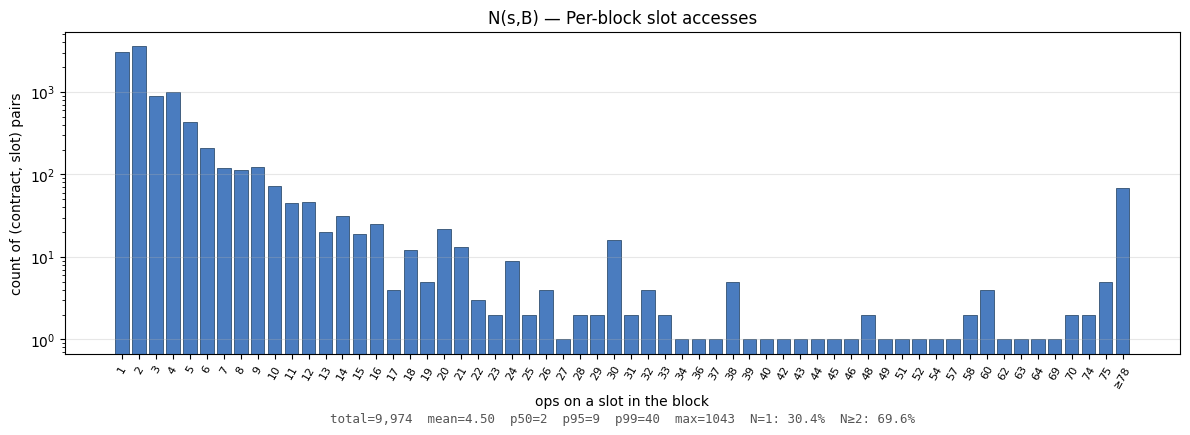

In [8]:
d = agg_distribution(results, "n_distribution")
plot_distribution(d, "N(s,B) — Per-block slot accesses",
                  "ops on a slot in the block", "count of (contract, slot) pairs")

## N(c,B) — Per-block account calls

Total calls to each contract within a block (entry points + CALL-family ops, summed across all transactions).

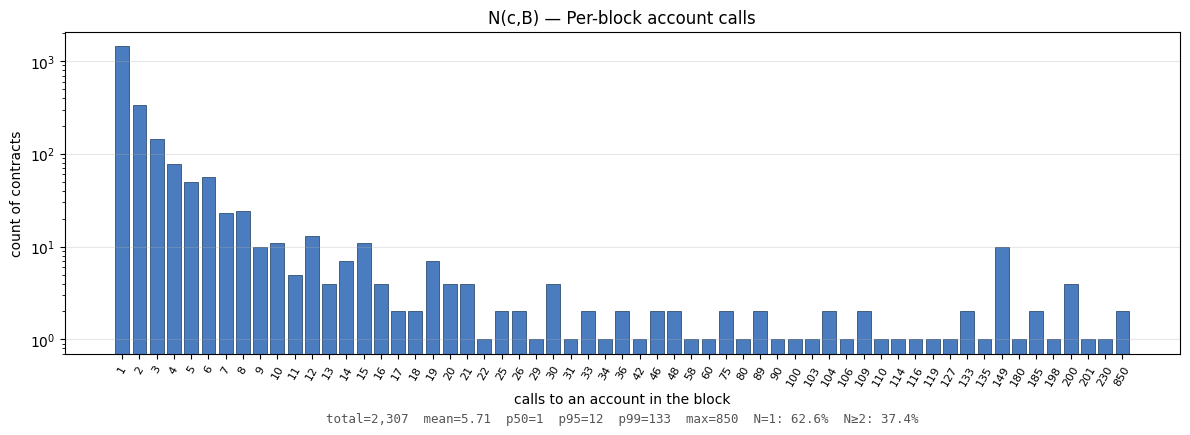

In [9]:
d = agg_distribution(results, "account_n_distribution")
plot_distribution(d, "N(c,B) — Per-block account calls",
                  "calls to an account in the block", "count of contracts")

## N(s,T) — Per-tx slot accesses

Number of SLOAD/SSTORE ops a single transaction performs on a given `(contract, slot)`.

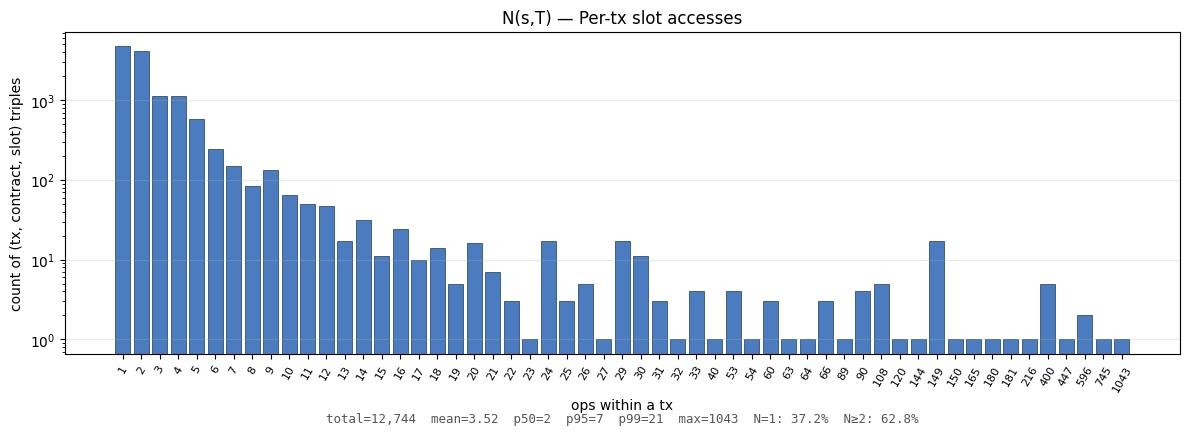

In [10]:
d = agg_distribution(results, "tx_slot_distribution")
plot_distribution(d, "N(s,T) — Per-tx slot accesses",
                  "ops within a tx", "count of (tx, contract, slot) triples")

## N(c,T) — Per-tx account calls

Number of times a single transaction calls a given contract (entry + CALL-family).

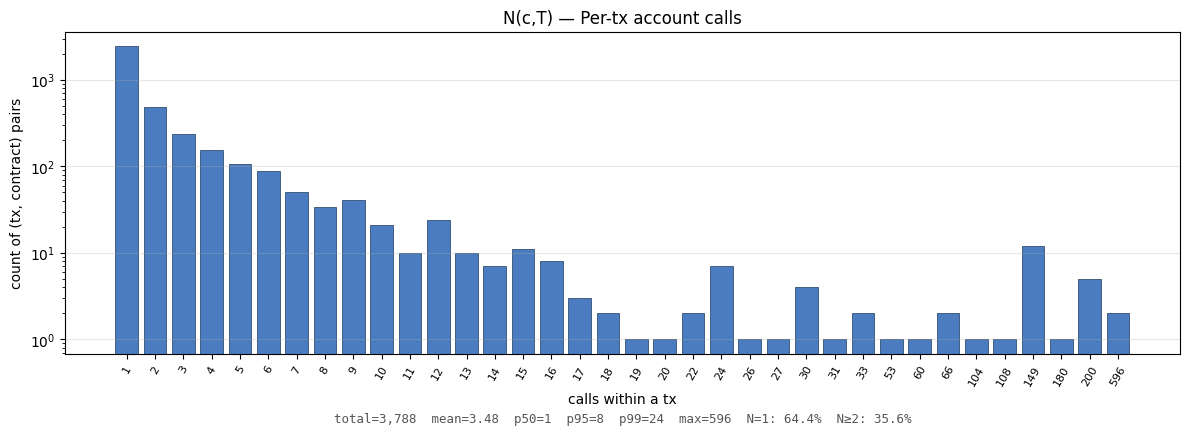

In [11]:
d = agg_distribution(results, "tx_account_distribution")
plot_distribution(d, "N(c,T) — Per-tx account calls",
                  "calls within a tx", "count of (tx, contract) pairs")

## Top (contract, slot) pairs by ops

In [12]:
slot_totals = defaultdict(int)
for r in results:
    for s in r["top_shared_slots"]:
        slot_totals[(s["contract"], s["slot"])] += s["n_ops"]
top_slots = sorted(slot_totals.items(), key=lambda x: x[1], reverse=True)[:20]

print(f"{'Contract':<44} {'Slot prefix':<14} N_ops")
print(f"{'─'*44} {'─'*14} {'─'*6}")
for (c, s), n in top_slots:
    print(f"{c:<44} {s[:12]}…  {n:>5,}")

Contract                                     Slot prefix    N_ops
──────────────────────────────────────────── ────────────── ──────
0x2b591e99afe9f32eaa6214f7b7629768c40eeb39   24ecb05b7556…  2,000
0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48   10d6a54a4754…  1,251
0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48   7050c9e0f4ca…  1,251
0x9b44efca3e2a707b63dc00ce79d646e5e5d24ba5   000000000000…  1,043
0xdac17f958d2ee523a2206206994597c13d831ec7   000000000000…    786
0x9b44efca3e2a707b63dc00ce79d646e5e5d24ba5   000000000000…    745
0xdac17f958d2ee523a2206206994597c13d831ec7   000000000000…    614
0xdac17f958d2ee523a2206206994597c13d831ec7   000000000000…    614
0xdac17f958d2ee523a2206206994597c13d831ec7   000000000000…    614
0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48   000000000000…    471
0x9b44efca3e2a707b63dc00ce79d646e5e5d24ba5   000000000000…    447
0xa2b4c0af19cc16a6cfacce81f192b024d625817d   000000000000…    360
0x29a56a1b8214d9cf7c5561811750d5cbdb45cc8e   000000000000…    300
0x0c9a3dd

## Top accounts by calls

In [13]:
acct_totals = defaultdict(int)
for r in results:
    for a in r["top_shared_accounts"]:
        acct_totals[a["account"]] += a["n_calls"]
top_accts = sorted(acct_totals.items(), key=lambda x: x[1], reverse=True)[:20]

print(f"{'Account':<44} N_calls")
print(f"{'─'*44} {'─'*7}")
for a, n in top_accts:
    print(f"{a:<44} {n:>6,}")

Account                                      N_calls
──────────────────────────────────────────── ───────
0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48    1,251
0x43506849d7c04f9138d1a2050bbf3a0c054402dd    1,250
0x2b591e99afe9f32eaa6214f7b7629768c40eeb39    1,001
0xdac17f958d2ee523a2206206994597c13d831ec7      788
0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2      432
0x000000000004444c5dc75cb358380d2e3de08a90      358
0x29a56a1b8214d9cf7c5561811750d5cbdb45cc8e      313
0x8ff1c814719096b61abf00bb46ead0c9a529dd7d      300
0x9b44efca3e2a707b63dc00ce79d646e5e5d24ba5      180
0xdfdc17f784e16d7634ac270911d98755c68ae220      149
0x696d02db93291651ed510704c9b286841d506987      149
0xd8063123bba3b480569244ae66bfe72b6c84b00d      149
0x968234f13e485e6c7ad3469238cc4e6005dd5d23      149
0xe0a80d35bb6618cba260120b279d357978c42bce      149
0x4610815e65901e66237ef07493a06cbac783c188      149
0x726104cfbd7ece2d1f5b3654a19109a9e2b6c27b      149
0xa7569a44f348d3d70d8ad5889e50f78e33d80d35      149
0xbbbbbbbb

## Export results

In [ ]:
# Uncomment to save raw JSON results:
# with open("results.json", "w") as f:
#     json.dump(results, f, indent=2)
# print("Saved to results.json")